### Подготовка датасета по показателю объем убоя верблюда

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

from pylab import rcParams
from IPython.display import display
import math
from prophet import Prophet
pd.set_option('display.max_columns', 130)


import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)



In [32]:
df = pd.read_excel("../../Data cleansing/output data/Просуммированные по категориям v2.xlsx")
df.head(5)

,Показатель,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
0,Верблюды,АКМОЛИНСКАЯ ОБЛАСТЬ,NaN,NaN,0.40,NaN,NaN,NaN,0.09,1.00,NaN,NaN,0.20,NaN,NaN,0.18,0.28,NaN,NaN,0.40,NaN,NaN,0.65,NaN,0.31,1.00,NaN,NaN,NaN,NaN,NaN,2.01,NaN,1.20,NaN,NaN,2.18,0.39,NaN,NaN,1.04,NaN,0.14,2.08,NaN,NaN,NaN,NaN,NaN,0.30,NaN,NaN,NaN,0.66,NaN,0.33,NaN,0.9,NaN,NaN,NaN,10.08,NaN,NaN,NaN,NaN,NaN,0.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Верблюды,АКТЮБИНСКАЯ ОБЛАСТЬ,101.98,67.47,374.84,115.59,218.72,14.15,19.77,3.00,39.16,46.16,238.56,463.35,109.04,72.94,384.96,114.35,221.89,10.93,18.79,3.50,38.53,46.64,216.08,472.07,110.32,68.17,380.15,127.12,217.61,14.98,21.26,7.14,44.63,51.78,239.43,513.33,115.70,69.40,371.53,130.17,218.41,14.59,21.76,7.19,45.97,55.48,252.68,527.66,117.94,70.37,385.75,117.80,218.45,15.54,21.78,7.2,47.06,58.02,257.54,543.35,119.80,71.3,396.90,121.8,228.10,15.90,21.9,7.2,63.00,59.90,260.20,552.10,121.60,71.8,398.40,128.50,228.80,13.10,22.50,7.20,63.90,61.90,150.70,554.90,121.30,73.3,404.20,128.70,234.90,13.60,23.60,6.3,49.80,62.4,153.70,552.8,118.07,69.17,384.21,121.01,223.46,11.76,21.39,5.52,48.18,61.39,150.87,531.79,119.50,72.60,391.0,126.1,229.10,12.2,24.10,5.7,49.87,63.00,154.3,538.40,129.3,77.60,411.5,128.1,235.70,12.2,25.17
2,Верблюды,АЛМАТИНСКАЯ ОБЛАСТЬ,1.00,0.20,51.60,25.40,NaN,61.90,76.87,95.57,16.09,0.10,10.80,46.78,15.06,13.70,131.80,9.20,17.89,130.12,2.00,NaN,4.99,2.06,4.90,44.48,15.06,23.94,41.60,19.54,3.00,15.14,18.50,14.82,14.52,12.60,9.92,43.11,20.72,2.96,15.24,NaN,1.00,20.03,3.44,7.77,117.25,1.00,NaN,20.34,21.95,3.04,17.91,26.81,9.16,18.80,13.37,NaN,17.29,15.90,4.69,23.10,10.85,9.7,42.75,NaN,6.21,21.10,4.0,2.6,28.10,4.53,79.50,93.18,23.70,11.2,16.00,2.00,3.10,19.62,2.30,4.85,11.18,2.80,9.65,36.44,10.60,11.5,26.10,7.20,12.75,11.20,11.20,27.0,25.26,17.9,21.90,12.5,16.55,16.81,22.78,12.10,12.44,6.85,39.65,17.22,8.85,27.48,0.48,29.72,18.90,17.40,12.5,16.4,11.60,16.7,15.70,24.0,7.70,6.90,5.4,12.60,22.6,19.00,8.2,12.0,40.70,41.6,28.10
3,Верблюды,АТЫРАУСКАЯ ОБЛАСТЬ,213.89,167.70,306.60,164.97,342.57,192.00,43.60,113.03,262.37,193.97,308.17,1087.33,325.10,190.60,301.10,154.84,328.50,220.30,66.10,118.20,234.90,196.51,270.92,974.18,303.30,167.41,323.54,182.34,349.10,249.40,57.57,88.40,221.21,199.63,278.80,964.02,305.22,159.62,326.87,159.50,367.20,257.50,60.01,78.10,253.27,332.00,355.05,989.86,280.08,165.05,334.51,134.85,367.97,321.22,126.22,93.7,263.10,366.66,348.54,1041.38,293.40,154.8,339.44,143.6,405.80,308.35,88.5,130.5,575.30,458.70,357.62,998.10,292.76,188.3,487.02,129.28,421.44,351.20,95.77,97.54,624.80,631.65,499.30,1179.66,286.67,189.8,513.16,171.46,402.10,432.22,121.53,126.2,637.50,651.7,482.94,1412.2,307.85,200.59,466.60,182.63,414.56,405.19,184.80,154.96,717.92,719.01,522.83,1164.77,323.81,423.76,441.9,219.1,487.69,446.9,191.43,133.5,730.34,709.68,537.6,

In [33]:
df['Показатель'].unique()

array(['Верблюды', 'КРС', 'Лошади', 'Молоко', 'Овцы и козы', 'Птица',
       'Свиньи', 'Яйца'], dtype=object)

In [40]:
df_camel = df[df['Показатель'].isin(['Верблюды'])]
df_camel.head()

,Показатель,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
0,Верблюды,АКМОЛИНСКАЯ ОБЛАСТЬ,NaN,NaN,0.40,NaN,NaN,NaN,0.09,1.00,NaN,NaN,0.20,NaN,NaN,0.18,0.28,NaN,NaN,0.40,NaN,NaN,0.65,NaN,0.31,1.00,NaN,NaN,NaN,NaN,NaN,2.01,NaN,1.20,NaN,NaN,2.18,0.39,NaN,NaN,1.04,NaN,0.14,2.08,NaN,NaN,NaN,NaN,NaN,0.30,NaN,NaN,NaN,0.66,NaN,0.33,NaN,0.9,NaN,NaN,NaN,10.08,NaN,NaN,NaN,NaN,NaN,0.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Верблюды,АКТЮБИНСКАЯ ОБЛАСТЬ,101.98,67.47,374.84,115.59,218.72,14.15,19.77,3.00,39.16,46.16,238.56,463.35,109.04,72.94,384.96,114.35,221.89,10.93,18.79,3.50,38.53,46.64,216.08,472.07,110.32,68.17,380.15,127.12,217.61,14.98,21.26,7.14,44.63,51.78,239.43,513.33,115.70,69.40,371.53,130.17,218.41,14.59,21.76,7.19,45.97,55.48,252.68,527.66,117.94,70.37,385.75,117.80,218.45,15.54,21.78,7.2,47.06,58.02,257.54,543.35,119.80,71.3,396.90,121.8,228.10,15.90,21.9,7.2,63.00,59.90,260.20,552.10,121.60,71.8,398.40,128.50,228.80,13.10,22.50,7.20,63.90,61.90,150.70,554.90,121.30,73.3,404.20,128.70,234.90,13.60,23.60,6.3,49.80,62.4,153.70,552.8,118.07,69.17,384.21,121.01,223.46,11.76,21.39,5.52,48.18,61.39,150.87,531.79,119.50,72.60,391.0,126.1,229.10,12.2,24.10,5.7,49.87,63.00,154.3,538.40,129.3,77.60,411.5,128.1,235.70,12.2,25.17
2,Верблюды,АЛМАТИНСКАЯ ОБЛАСТЬ,1.00,0.20,51.60,25.40,NaN,61.90,76.87,95.57,16.09,0.10,10.80,46.78,15.06,13.70,131.80,9.20,17.89,130.12,2.00,NaN,4.99,2.06,4.90,44.48,15.06,23.94,41.60,19.54,3.00,15.14,18.50,14.82,14.52,12.60,9.92,43.11,20.72,2.96,15.24,NaN,1.00,20.03,3.44,7.77,117.25,1.00,NaN,20.34,21.95,3.04,17.91,26.81,9.16,18.80,13.37,NaN,17.29,15.90,4.69,23.10,10.85,9.7,42.75,NaN,6.21,21.10,4.0,2.6,28.10,4.53,79.50,93.18,23.70,11.2,16.00,2.00,3.10,19.62,2.30,4.85,11.18,2.80,9.65,36.44,10.60,11.5,26.10,7.20,12.75,11.20,11.20,27.0,25.26,17.9,21.90,12.5,16.55,16.81,22.78,12.10,12.44,6.85,39.65,17.22,8.85,27.48,0.48,29.72,18.90,17.40,12.5,16.4,11.60,16.7,15.70,24.0,7.70,6.90,5.4,12.60,22.6,19.00,8.2,12.0,40.70,41.6,28.10
3,Верблюды,АТЫРАУСКАЯ ОБЛАСТЬ,213.89,167.70,306.60,164.97,342.57,192.00,43.60,113.03,262.37,193.97,308.17,1087.33,325.10,190.60,301.10,154.84,328.50,220.30,66.10,118.20,234.90,196.51,270.92,974.18,303.30,167.41,323.54,182.34,349.10,249.40,57.57,88.40,221.21,199.63,278.80,964.02,305.22,159.62,326.87,159.50,367.20,257.50,60.01,78.10,253.27,332.00,355.05,989.86,280.08,165.05,334.51,134.85,367.97,321.22,126.22,93.7,263.10,366.66,348.54,1041.38,293.40,154.8,339.44,143.6,405.80,308.35,88.5,130.5,575.30,458.70,357.62,998.10,292.76,188.3,487.02,129.28,421.44,351.20,95.77,97.54,624.80,631.65,499.30,1179.66,286.67,189.8,513.16,171.46,402.10,432.22,121.53,126.2,637.50,651.7,482.94,1412.2,307.85,200.59,466.60,182.63,414.56,405.19,184.80,154.96,717.92,719.01,522.83,1164.77,323.81,423.76,441.9,219.1,487.69,446.9,191.43,133.5,730.34,709.68,537.6,

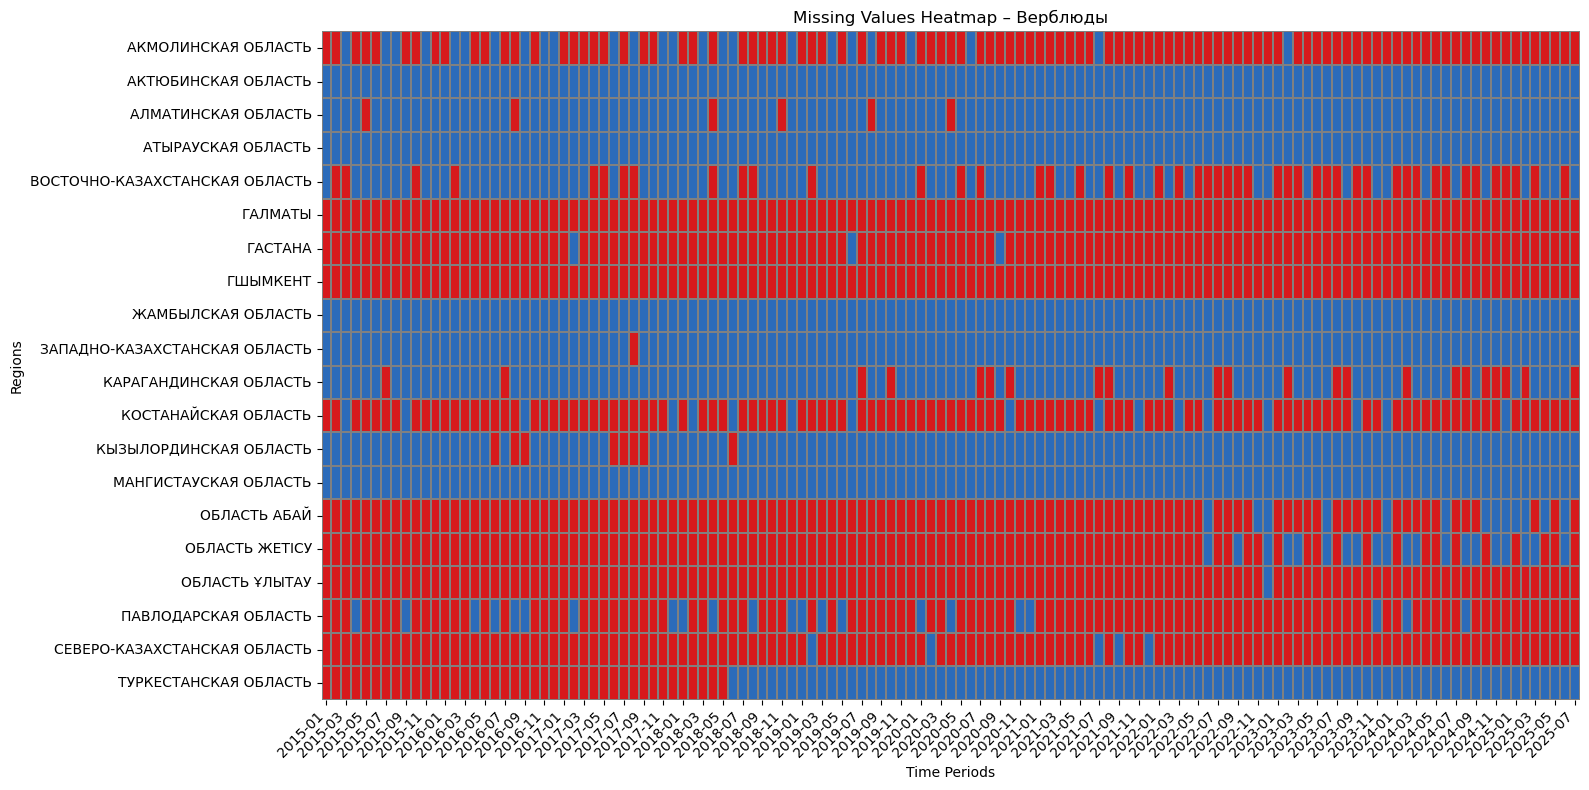

In [41]:
period_cols = [c for c in df_camel.columns if c not in ["Показатель", "Регион"]]
missing_matrix = (
    df_camel.set_index("Регион")[period_cols]
          .isna()
          .astype(int)
)
plt.figure(figsize=(16, 8))
sns.heatmap(
    missing_matrix,
    cmap=["#2b6bba", "#d7191c"],   # blue = data present, red = missing
    cbar=False,
    linewidths=0.3,
    linecolor="grey"
)

plt.title("Missing Values Heatmap – Верблюды")
plt.xlabel("Time Periods")
plt.ylabel("Regions")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [42]:
df_camel.groupby("Регион").apply(lambda g: g.isna().sum().sum())



Регион
АКМОЛИНСКАЯ ОБЛАСТЬ               102
АКТЮБИНСКАЯ ОБЛАСТЬ                 0
АЛМАТИНСКАЯ ОБЛАСТЬ                 6
АТЫРАУСКАЯ ОБЛАСТЬ                  0
ВОСТОЧНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ     48
ГАЛМАТЫ                           127
ГАСТАНА                           124
ГШЫМКЕНТ                          127
ЖАМБЫЛСКАЯ ОБЛАСТЬ                  0
ЗАПАДНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ       1
КАРАГАНДИНСКАЯ ОБЛАСТЬ             23
КОСТАНАЙСКАЯ ОБЛАСТЬ              110
КЫЗЫЛОРДИНСКАЯ ОБЛАСТЬ              8
МАНГИСТАУСКАЯ ОБЛАСТЬ               0
ОБЛАСТЬ АБАЙ                      114
ОБЛАСТЬ ЖЕТІСУ                    107
ОБЛАСТЬ ҰЛЫТАУ                    126
ПАВЛОДАРСКАЯ ОБЛАСТЬ              105
СЕВЕРО-КАЗАХСТАНСКАЯ ОБЛАСТЬ      122
ТУРКЕСТАНСКАЯ ОБЛАСТЬ              41
dtype: int64

In [37]:
# Step 1: Pivot to wide format (each indicator becomes columns of periods)
df_wide = df_camel.pivot(index="Регион", columns="Показатель")

# Step 2: Flatten multi-level columns: ('2015-01', 'КРС') → 'КРС_2015-01'
df_wide.columns = [f"{col[1]}_{col[0]}" for col in df_wide.columns]
df_wide = df_wide.reset_index()

# Step 3: Melt: one row per region-period-indicator
df_melted = df_wide.melt(id_vars="Регион", var_name="indicator_period", value_name="value")

# Step 4: Extract 'Период' and 'Показатель' from the combined column
df_melted["Период"] = df_melted["indicator_period"].str.extract(r"_(\d{4}-\d{2})$")
df_melted["Показатель"] = df_melted["indicator_period"].str.extract(r"^(.+)_\d{4}-\d{2}")

# Step 5: Pivot again to get final modeling format: one row per region+period, one column per indicator
df_camel = df_melted.pivot_table(index=["Регион", "Период"], columns="Показатель", values="value").reset_index()
print(df_camel.groupby("Регион").size().reset_index(name="Количество строк"))
df_camel

                            Регион  Количество строк
0              АКМОЛИНСКАЯ ОБЛАСТЬ                25
1              АКТЮБИНСКАЯ ОБЛАСТЬ               127
2              АЛМАТИНСКАЯ ОБЛАСТЬ               121
3               АТЫРАУСКАЯ ОБЛАСТЬ               127
4   ВОСТОЧНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ                79
5                          ГАСТАНА                 3
6               ЖАМБЫЛСКАЯ ОБЛАСТЬ               127
7    ЗАПАДНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ               126
8           КАРАГАНДИНСКАЯ ОБЛАСТЬ               104
9             КОСТАНАЙСКАЯ ОБЛАСТЬ                17
10          КЫЗЫЛОРДИНСКАЯ ОБЛАСТЬ               119
11           МАНГИСТАУСКАЯ ОБЛАСТЬ               127
12                    ОБЛАСТЬ АБАЙ                13
13                  ОБЛАСТЬ ЖЕТІСУ                20
14                  ОБЛАСТЬ ҰЛЫТАУ                 1
15            ПАВЛОДАРСКАЯ ОБЛАСТЬ                22
16    СЕВЕРО-КАЗАХСТАНСКАЯ ОБЛАСТЬ                 5
17           ТУРКЕСТАНСКАЯ ОБЛАСТЬ            

Показатель,Регион,Период,Верблюды
0,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-03,0.40
1,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-07,0.09
2,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-08,1.00
3,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-11,0.20
4,АКМОЛИНСКАЯ ОБЛАСТЬ,2016-02,0.18
...,...,...,...
1244,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2025-03,93.10
1245,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2025-04,85.80
1246,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2025-05,96.61
1247,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2025-06,105.00


In [38]:
df_camel['Регион'].nunique()

18

In [39]:
df_camel.to_excel("Датасет по верблюдам v2.xlsx", index=False)

In [20]:
# 1) приведение типов
df = df_camel.copy()
df["Период"] = pd.to_datetime(df["Период"], format="%Y-%m", errors="coerce")
df["Верблюды"] = pd.to_numeric(df["Верблюды"], errors="coerce")

# 2) wide-таблица: строки — месяцы, столбцы — регионы, значения — КРС
df_camel_wide = (df
        .pivot_table(index="Период", columns="Регион", values="Верблюды", aggfunc="sum")  # если дублей нет — можно aggfunc="first"
        .sort_index())
# 3) Убираем лишний уровень индекса у колонок
df_camel_wide.columns.name = None

# 4) Возвращаем "Период" в строковый формат YYYY-MM
df_camel_wide = df_camel_wide.reset_index()
df_camel_wide["Период"] = df_camel_wide["Период"].dt.strftime("%Y-%m")

df_camel_wide.to_excel("Датасет по верблюдам wide.xlsx", index=False)
df_camel_wide

,Период,АКМОЛИНСКАЯ ОБЛАСТЬ,АКТЮБИНСКАЯ ОБЛАСТЬ,АЛМАТИНСКАЯ ОБЛАСТЬ,АТЫРАУСКАЯ ОБЛАСТЬ,ВОСТОЧНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,ГАСТАНА,ЖАМБЫЛСКАЯ ОБЛАСТЬ,ЗАПАДНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,КАРАГАНДИНСКАЯ ОБЛАСТЬ,КОСТАНАЙСКАЯ ОБЛАСТЬ,КЫЗЫЛОРДИНСКАЯ ОБЛАСТЬ,МАНГИСТАУСКАЯ ОБЛАСТЬ,ОБЛАСТЬ АБАЙ,ОБЛАСТЬ ЖЕТІСУ,ОБЛАСТЬ ҰЛЫТАУ,ПАВЛОДАРСКАЯ ОБЛАСТЬ,СЕВЕРО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,ТУРКЕСТАНСКАЯ ОБЛАСТЬ
0,2015-01,NaN,101.98,1.0,213.89,0.30,NaN,68.46,5.81,1.56,NaN,277.14,175.14,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-02,NaN,67.47,0.2,167.70,NaN,NaN,36.10,5.34,3.14,NaN,191.49,128.30,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-03,0.4,374.84,51.6,306.60,NaN,NaN,64.29,8.80,9.45,0.38,178.37,87.04,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-04,NaN,115.59,25.4,164.97,1.14,NaN,22.05,4.15,6.87,NaN,110.29,45.57,NaN,NaN,NaN,0.96,NaN,NaN
4,2015-05,NaN,218.72,NaN,342.57,6.12,NaN,6.70,15.82,3.45,NaN,2.80,210.00,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,2025-03,NaN,411.50,8.2,447.40,NaN,NaN,60.40,9.70,9.80,NaN,335.32,109.58,NaN,1.1,NaN,NaN,NaN,93.10
123,2025-04,NaN,128.10,12.0,266.80,2.90,NaN,18.20,1.70,2.00,NaN,72.20,94.70,0.35,NaN,NaN,NaN,NaN,85.80
124,2025-05,NaN,235.70,40.7,496.55,0.90,NaN,15.60,9.60,6.30,NaN,1.51,174.45,NaN,NaN,NaN,NaN,NaN,96.61
125,2025-06,NaN,12.20,41.6,688.00,NaN,NaN,19.70,59.92,6.40,NaN,56.94,317.85,3.98,28.3,NaN,NaN,NaN,105.00
